# Section 7: Subspace Dynamics Analysis

**Core question**: Do PSID/DPAD latents encode DBS-ON vs DBS-OFF, and does DBS shift the learned dynamics (A, Cy, Cz matrices)?

All significance tests use FDR correction (Benjamini-Hochberg, q<0.05) across dims/features.

| § | Analysis | Frameworks | Source |
|---|----------|------------|--------|
| 3 | Xp Cohen's d histogram + Xp1/Xp2 coloring | PSID, DPAD (separate figures) | test set |
| 4 | A-matrix L1 + t-test across dbs_both/on/off | PSID | model |
| 5 | (included in §3) | — | — |
| 6 | Xf Cohen's d histogram (h=0.5s) | PSID, DPAD (separate figures) | test set |
| 7 | Cy, Cz L1 + t-test across dbs_both/on/off | PSID | model |

In [1]:
import sys, os

os.chdir("/home/bobby/repos/latent-neural-dynamics-modeling")
sys.path.insert(0, ".")
sys.path.insert(0, "notebooks")

In [2]:
from pathlib import Path
import importlib
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from modules.sec7_common import (
    get_neural_channels_from_config,
    load_test_trials,
    load_xp_by_stim,
    load_xf_by_stim,
    load_model_matrices,
    cohens_d_histogram,
    feature_trial_stats,
    print_matrix_comparison,
    print_cohens_d_stats,
)

pkl_mod = importlib.import_module("pic" + "kle")  # nosec — trusted in-repo outputs

def load_model(path):
    with open(path, "rb") as f:
        return pkl_mod.load(f)

from modules.style import (
    COLOR_PSID,
    COLOR_DPAD,
    apply_thesis_style,
    panel_label,
)

apply_thesis_style()

OUT = Path("thesis_figures/sec7")
OUT.mkdir(parents=True, exist_ok=True)
from modules.loaders import pretty_exp


## 1. Configuration

Each entry specifies the PSID model paths (both, ON-only, OFF-only),
data location, and subspace dimensions (n1 = behavioral dims, nx = total dims).

In [3]:
RUNS = [
    {
        "label": "PDI1 S2",
        "model_type": "psid",
        "participant": "PDI1",
        "session": "S2",
        "n1": 1,
        "nx": 64,
        "fs": 200,
        "variant": "psid_z-as-behavior_PDI1_S2_nx_64_n1_1",
        "config_yaml": "training/setups/psid_PDI1_S2_z-as-behavior.yaml",
        "model_both": "results/psid/psid_z-as-behavior_PDI1_S2_nx_64_n1_1_dbs_both/model_20260511_203314.pkl",
        "model_on":   "results/psid/psid_z-as-behavior_PDI1_S2_nx_64_n1_1_dbs_on/model_20260511_203715.pkl",
        "model_off":  "results/psid/psid_z-as-behavior_PDI1_S2_nx_64_n1_1_dbs_off/model_20260511_203952.pkl",
    },
    {
        "label": "PDI1 S4",
        "model_type": "psid",
        "participant": "PDI1",
        "session": "S4",
        "n1": 8,
        "nx": 64,
        "fs": 200,
        "variant": "psid_z-as-behavior_PDI1_S4_nx_64_n1_8",
        "config_yaml": "training/setups/psid_PDI1_S4_z-as-behavior.yaml",
        "model_both": "results/psid/psid_z-as-behavior_PDI1_S4_nx_64_n1_8_dbs_both/model_20260511_205028.pkl",
        "model_on":   "results/psid/psid_z-as-behavior_PDI1_S4_nx_64_n1_8_dbs_on/model_20260511_205157.pkl",
        "model_off":  "results/psid/psid_z-as-behavior_PDI1_S4_nx_64_n1_8_dbs_off/model_20260511_205243.pkl",
    },
    {
        "label": "PDI4 S2",
        "model_type": "psid",
        "participant": "PDI4",
        "session": "S2",
        "n1": 1,
        "nx": 64,
        "fs": 200,
        "variant": "psid_z-as-behavior_PDI4_S2_nx_64_n1_1",
        "config_yaml": "training/setups/psid_PDI4_S2_z-as-behavior.yaml",
        "model_both": "results/psid/psid_z-as-behavior_PDI4_S2_nx_64_n1_1_dbs_both/model_20260511_205945.pkl",
        "model_on":   "results/psid/psid_z-as-behavior_PDI4_S2_nx_64_n1_1_dbs_on/model_20260511_210108.pkl",
        "model_off":  "results/psid/psid_z-as-behavior_PDI4_S2_nx_64_n1_1_dbs_off/model_20260511_210148.pkl",
    },
    {
        "label": "PDI4 S3",
        "model_type": "psid",
        "participant": "PDI4",
        "session": "S3",
        "n1": 1,
        "nx": 64,
        "fs": 200,
        "variant": "psid_z-as-behavior_PDI4_S3_nx_64_n1_1",
        "config_yaml": "training/setups/psid_PDI4_S3_z-as-behavior.yaml",
        "model_both": "results/psid/psid_z-as-behavior_PDI4_S3_nx_64_n1_1_dbs_both/model_20260511_210902.pkl",
        "model_on":   "results/psid/psid_z-as-behavior_PDI4_S3_nx_64_n1_1_dbs_on/model_20260511_211026.pkl",
        "model_off":  "results/psid/psid_z-as-behavior_PDI4_S3_nx_64_n1_1_dbs_off/model_20260511_211110.pkl",
    },
]

## 2. Load data and models (test set only)

Load **test-set** trials from split parquets and PSID models (both, ON-only, OFF-only).
All analyses use test-set data for consistency with other thesis notebooks.

In [4]:
data = {}

for run in RUNS:
    label = run["label"]
    mtype = run["model_type"]
    n1, nx, fs = run["n1"], run["nx"], run["fs"]

    neural_channels = get_neural_channels_from_config(run["config_yaml"])
    Y_all, Xp_all, labels, df = load_test_trials(run["variant"])

    model_both = load_model(run["model_both"])
    model_on = load_model(run["model_on"]) if "model_on" in run else None
    model_off = load_model(run["model_off"]) if "model_off" in run else None

    Xp_on = [Xp_all[i] for i in range(len(labels)) if labels[i] == 1]
    Xp_off = [Xp_all[i] for i in range(len(labels)) if labels[i] == 0]

    data[label] = {
        "run": run,
        "n1": n1,
        "nx": nx,
        "fs": fs,
        "model_type": mtype,
        "neural_channels": neural_channels,
        "df": df,
        "labels": labels,
        "model_both": model_both,
        "model_on": model_on,
        "model_off": model_off,
        "Xp_all": Xp_all,
        "Xp_on": Xp_on,
        "Xp_off": Xp_off,
    }
    print(
        f"  {label}: {sum(labels==1)} ON, {sum(labels==0)} OFF trials, "
        f"{len(neural_channels)} ch, Xp shape {Xp_all[0].shape}"
    )

  PDI1 S2: 24 ON, 24 OFF trials, 12 ch, Xp shape (1800, 64)


  PDI1 S4: 23 ON, 22 OFF trials, 12 ch, Xp shape (1800, 64)


  PDI4 S2: 24 ON, 24 OFF trials, 12 ch, Xp shape (1800, 64)


  PDI4 S3: 24 ON, 24 OFF trials, 12 ch, Xp shape (1800, 64)


## 3. Xp Cohen's d histogram — PSID + DPAD

Cohen's d per latent dimension (ON vs OFF trial means), BH-FDR corrected across all nx=64 dims.
Histogram: x-axis = Cohen's d value; light fill = all dims, solid fill = FDR significant (q<0.05).
Red = X_1 (first n1 dims), model-color = X_2 (remaining dims). Separate figures for PSID and DPAD.

PSID n1 is session-specific (behavioral subspace from A-matrix eigendecomposition).
DPAD n1=4 for all sessions (from training config).

BH-FDR is appropriate for this analysis: we have 64 independent hypothesis tests (one per dim),
and BH-FDR controls the expected proportion of false discoveries at q<0.05. It is valid under
positive dependency (Benjamini-Yekutieli), which typically holds for correlated latent states.

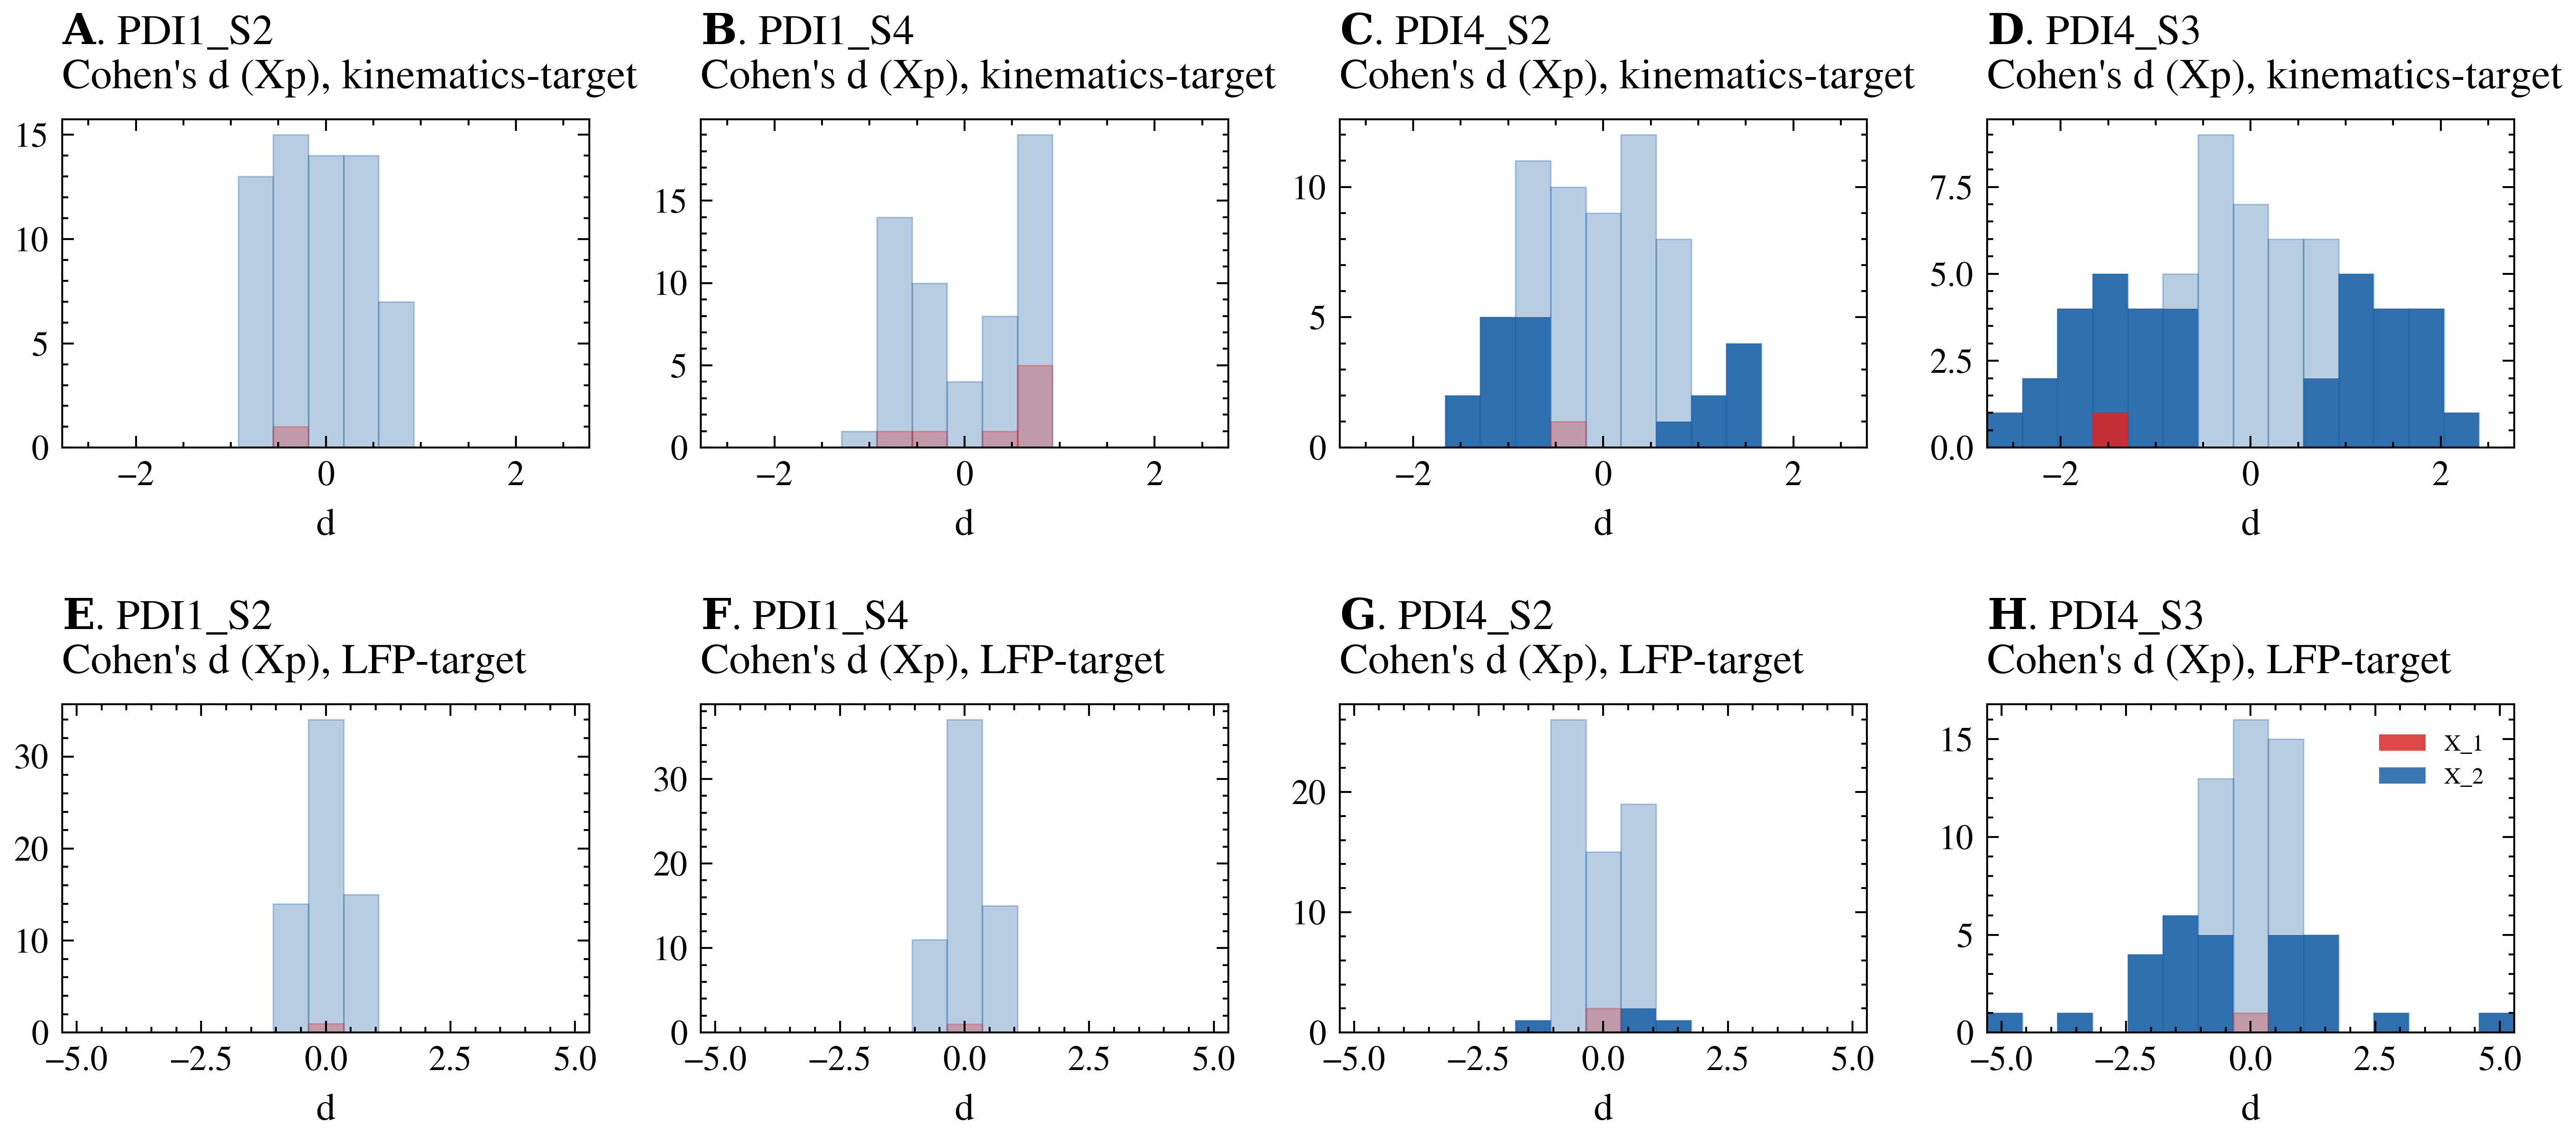


PSID Xp Cohen's d stats:
  [psid] PDI1_S2 / z-as-behavior: n_sig=0/64, mean|d|=0.414, max|d|=0.871
    X_1 (n=1): n_sig=0/1, mean|d|=0.439
    X_2 (n=63): n_sig=0/63, mean|d|=0.414
  [psid] PDI1_S4 / z-as-behavior: n_sig=0/64, mean|d|=0.579, max|d|=0.930
    X_1 (n=8): n_sig=0/8, mean|d|=0.651
    X_2 (n=56): n_sig=0/56, mean|d|=0.569
  [psid] PDI4_S2 / z-as-behavior: n_sig=19/64, mean|d|=0.602, max|d|=1.572
    X_1 (n=1): n_sig=0/1, mean|d|=0.422
    X_2 (n=63): n_sig=19/63, mean|d|=0.605
  [psid] PDI4_S3 / z-as-behavior: n_sig=37/64, mean|d|=0.973, max|d|=2.522
    X_1 (n=1): n_sig=1/1, mean|d|=1.533
    X_2 (n=63): n_sig=36/63, mean|d|=0.964
  [psid] PDI1_S2 / z-as-neural: n_sig=0/64, mean|d|=0.378, max|d|=0.907
    X_1 (n=1): n_sig=0/1, mean|d|=0.224
    X_2 (n=63): n_sig=0/63, mean|d|=0.380
  [psid] PDI1_S4 / z-as-neural: n_sig=0/64, mean|d|=0.336, max|d|=0.987
    X_1 (n=1): n_sig=0/1, mean|d|=0.345
    X_2 (n=63): n_sig=0/63, mean|d|=0.336
  [psid] PDI4_S2 / z-as-neural: n_sig=

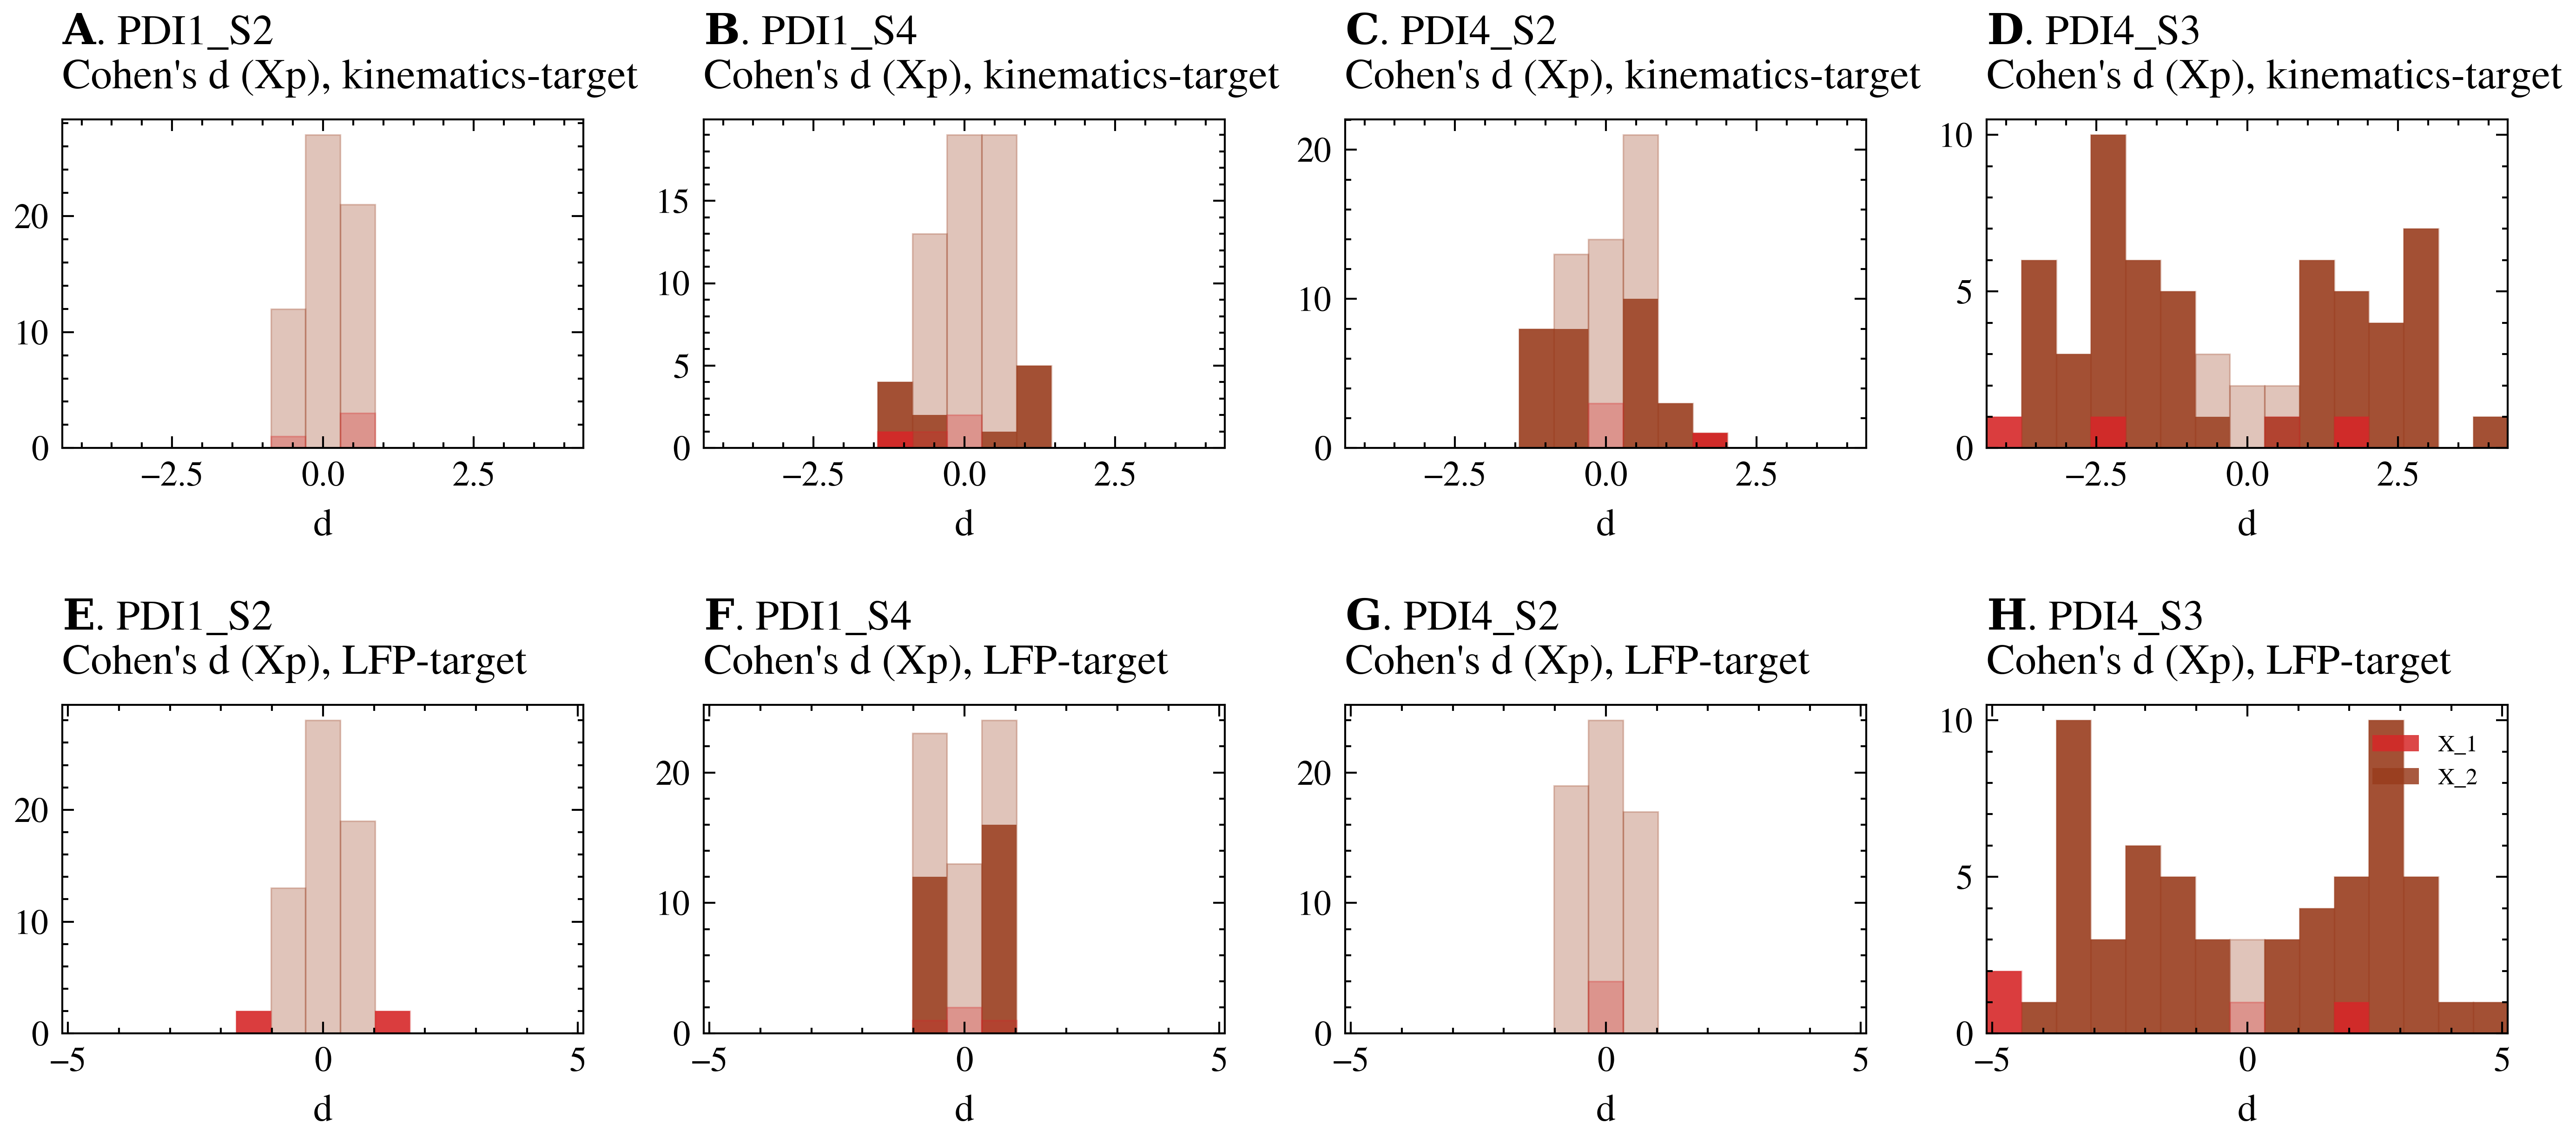


DPAD Xp Cohen's d stats:
  [dpad] PDI1_S2 / z-as-behavior: n_sig=0/64, mean|d|=0.346, max|d|=0.759
    X_1 (n=4): n_sig=0/4, mean|d|=0.520
    X_2 (n=60): n_sig=0/60, mean|d|=0.334
  [dpad] PDI1_S4 / z-as-behavior: n_sig=13/64, mean|d|=0.498, max|d|=1.047
    X_1 (n=4): n_sig=1/4, mean|d|=0.466
    X_2 (n=60): n_sig=12/60, mean|d|=0.500
  [dpad] PDI4_S2 / z-as-behavior: n_sig=31/64, mean|d|=0.601, max|d|=1.522
    X_1 (n=4): n_sig=1/4, mean|d|=0.469
    X_2 (n=60): n_sig=30/60, mean|d|=0.610
  [dpad] PDI4_S3 / z-as-behavior: n_sig=58/64, mean|d|=2.011, max|d|=3.926
    X_1 (n=4): n_sig=3/4, mean|d|=2.019
    X_2 (n=60): n_sig=55/60, mean|d|=2.010
  [dpad] PDI1_S2 / z-as-neural: n_sig=4/64, mean|d|=0.372, max|d|=1.184
    X_1 (n=4): n_sig=4/4, mean|d|=1.111
    X_2 (n=60): n_sig=0/60, mean|d|=0.322
  [dpad] PDI1_S4 / z-as-neural: n_sig=28/64, mean|d|=0.588, max|d|=0.836
    X_1 (n=4): n_sig=0/4, mean|d|=0.381
    X_2 (n=60): n_sig=28/60, mean|d|=0.602
  [dpad] PDI4_S2 / z-as-neural: n_

In [5]:
PSID_NEURAL_VARIANTS = {
    "PDI1 S2": ("psid_z-as-neural_PDI1_S2_nx_64_n1_1", 1),
    "PDI1 S4": ("psid_z-as-neural_PDI1_S4_nx_64_n1_1", 1),
    "PDI4 S2": ("psid_z-as-neural_PDI4_S2_nx_64_n1_2", 2),
    "PDI4 S3": ("psid_z-as-neural_PDI4_S3_nx_64_n1_1", 1),
}

DPAD_BEHAVIOR_VARIANTS = {
    "PDI1 S2": "dpad_z-as-behavior_PDI1_S2_nx_64_n1_4_e1000",
    "PDI1 S4": "dpad_z-as-behavior_PDI1_S4_nx_64_n1_4_e1000",
    "PDI4 S2": "dpad_z-as-behavior_PDI4_S2_nx_64_n1_4_e1000",
    "PDI4 S3": "dpad_z-as-behavior_PDI4_S3_nx_64_n1_4_e1000",
}
DPAD_NEURAL_VARIANTS = {
    "PDI1 S2": "dpad_z-as-neural_PDI1_S2_nx_64_n1_4_e1000",
    "PDI1 S4": "dpad_z-as-neural_PDI1_S4_nx_64_n1_4_e1000",
    "PDI4 S2": "dpad_z-as-neural_PDI4_S2_nx_64_n1_4_e1000",
    "PDI4 S3": "dpad_z-as-neural_PDI4_S3_nx_64_n1_4_e1000",
}
DPAD_N1 = 4  # n1 from DPAD training config (same across all sessions/experiments)

sessions_list = list(data.keys())
n_sessions = len(sessions_list)

# --- pre-compute per-dim d + sig ------------------------------------------
XP_STATS = {}  # (framework, exp_full, session) -> (d_arr, sig, n1)

for session in sessions_list:
    # PSID behavioral
    Xp_all = data[session]["Xp_all"]
    labels_s = data[session]["labels"]
    stats_out = feature_trial_stats(Xp_all, labels_s)
    XP_STATS[("psid", "z-as-behavior", session)] = (
        np.array([r["d"] for r in stats_out]),
        np.array([r["reject_fdr"] for r in stats_out]),
        data[session]["n1"],
    )
    # PSID neural
    variant, n1 = PSID_NEURAL_VARIANTS[session]
    _, Xp_all, labels_s, _ = load_test_trials(variant)
    stats_out = feature_trial_stats(Xp_all, labels_s)
    XP_STATS[("psid", "z-as-neural", session)] = (
        np.array([r["d"] for r in stats_out]),
        np.array([r["reject_fdr"] for r in stats_out]),
        n1,
    )

for session in sessions_list:
    # DPAD behavioral
    variant = DPAD_BEHAVIOR_VARIANTS[session]
    Xp_on, Xp_off, _ = load_xp_by_stim(variant, framework="dpad", condition="dbs_both")
    Xp_all = Xp_on + Xp_off
    labels_s = np.array([1] * len(Xp_on) + [0] * len(Xp_off))
    stats_out = feature_trial_stats(Xp_all, labels_s)
    XP_STATS[("dpad", "z-as-behavior", session)] = (
        np.array([r["d"] for r in stats_out]),
        np.array([r["reject_fdr"] for r in stats_out]),
        DPAD_N1,
    )
    # DPAD neural
    variant = DPAD_NEURAL_VARIANTS[session]
    Xp_on, Xp_off, _ = load_xp_by_stim(variant, framework="dpad", condition="dbs_both")
    Xp_all = Xp_on + Xp_off
    labels_s = np.array([1] * len(Xp_on) + [0] * len(Xp_off))
    stats_out = feature_trial_stats(Xp_all, labels_s)
    XP_STATS[("dpad", "z-as-neural", session)] = (
        np.array([r["d"] for r in stats_out]),
        np.array([r["reject_fdr"] for r in stats_out]),
        DPAD_N1,
    )

EXP_NAMES = ["z-as-behavior", "z-as-neural"]

# ---- PSID figure ---------------------------------------------------------
fig, axes = plt.subplots(2, n_sessions, figsize=(2.3 * n_sessions, 4.2))
if n_sessions == 1:
    axes = axes.reshape(2, 1)

vlim_psid = {}
for row_idx, exp_name in enumerate(EXP_NAMES):
    all_d = np.concatenate([XP_STATS[("psid", exp_name, s)][0] for s in sessions_list])
    vlim_psid[exp_name] = max(float(np.abs(all_d).max()), 0.1) * 1.1

for col_idx, session in enumerate(sessions_list):
    for row_idx, exp_name in enumerate(EXP_NAMES):
        ax = axes[row_idx, col_idx]
        d_arr, sig, n1 = XP_STATS[("psid", exp_name, session)]
        cohens_d_histogram(ax, d_arr, sig, n1=n1, color=COLOR_PSID, vlim=vlim_psid[exp_name])
        letter = chr(65 + row_idx * n_sessions + col_idx)
        session_us = session.replace(" ", "_")
        panel_label(ax, letter, f"{session_us}\nCohen's d (Xp), {pretty_exp(exp_name)}")

legend_psid = [
    Patch(facecolor="tab:red", alpha=0.85, label="X_1"),
    Patch(facecolor=COLOR_PSID, alpha=0.85, label="X_2"),
]
axes[-1, -1].legend(handles=legend_psid, loc="upper right", fontsize=6)

fig.savefig(str(OUT / "xp_psid_cohens_d_hist.png"))
plt.show()
print("\nPSID Xp Cohen's d stats:")
print_cohens_d_stats({k: v for k, v in XP_STATS.items() if k[0] == "psid"})

# ---- DPAD figure ---------------------------------------------------------
fig, axes = plt.subplots(2, n_sessions, figsize=(2.3 * n_sessions, 4.2))
if n_sessions == 1:
    axes = axes.reshape(2, 1)

vlim_dpad = {}
for row_idx, exp_name in enumerate(EXP_NAMES):
    all_d = np.concatenate([XP_STATS[("dpad", exp_name, s)][0] for s in sessions_list])
    vlim_dpad[exp_name] = max(float(np.abs(all_d).max()), 0.1) * 1.1

for col_idx, session in enumerate(sessions_list):
    for row_idx, exp_name in enumerate(EXP_NAMES):
        ax = axes[row_idx, col_idx]
        d_arr, sig, n1 = XP_STATS[("dpad", exp_name, session)]
        cohens_d_histogram(ax, d_arr, sig, n1=n1, color=COLOR_DPAD, vlim=vlim_dpad[exp_name])
        letter = chr(65 + row_idx * n_sessions + col_idx)
        session_us = session.replace(" ", "_")
        panel_label(ax, letter, f"{session_us}\nCohen's d (Xp), {pretty_exp(exp_name)}")

legend_dpad = [
    Patch(facecolor="tab:red", alpha=0.85, label="X_1"),
    Patch(facecolor=COLOR_DPAD, alpha=0.85, label="X_2"),
]
axes[-1, -1].legend(handles=legend_dpad, loc="upper right", fontsize=6)

fig.savefig(str(OUT / "xp_dpad_cohens_d_hist.png"))
plt.show()
print("\nDPAD Xp Cohen's d stats:")
print_cohens_d_stats({k: v for k, v in XP_STATS.items() if k[0] == "dpad"})

## 4. A-matrix statistical comparison — PSID

L1 norm + one-sided t-test on element-wise differences between dbs_both, dbs_on, dbs_off models.
Sub-blocks (Xp1/Xp1, Xp1/Xp2, Xp2/Xp1, Xp2/Xp2) reported per comparison. Text output only.

In [6]:
# --- A-matrix statistical comparison (L1 norm + one-sided t-test) ----------
sessions_list = list(data.keys())
CONDS = ["dbs_both", "dbs_on", "dbs_off"]

for exp_label, variant_bases, n1_by_session in [
    (
        "z-as-behavior",
        {s: data[s]["run"]["variant"] for s in sessions_list},
        {s: data[s]["n1"] for s in sessions_list},
    ),
    (
        "z-as-neural",
        {s: PSID_NEURAL_VARIANTS[s][0] for s in sessions_list},
        {s: PSID_NEURAL_VARIANTS[s][1] for s in sessions_list},
    ),
]:
    for session in sessions_list:
        mats = {
            cond: load_model_matrices(variant_bases[session], cond)["A"]
            for cond in CONDS
        }
        print_matrix_comparison(
            f"A-matrix  {session}  {pretty_exp(exp_label)}",
            mats,
            n1_by_session[session],
        )


── A-matrix  PDI1 S2  kinematics-target ──
        pair          L1      mean Δ         t     p(H1: >0)     p(H1: <0)
--------------------------------------------------------------------------
dbs_on vs dbs_both    175.8066      0.0006     0.261        0.3971        0.6029
  block   11      0.0032      0.0032
  block   12      0.0000      0.0000
  block   21      0.2275     -0.0009
  block   22    175.5759      0.0006
dbs_off vs dbs_both    165.9270      0.0007     0.309        0.3788        0.6212
  block   11      0.0002     -0.0002
  block   12      0.0000      0.0000
  block   21      0.1960     -0.0006
  block   22    165.7308      0.0007
dbs_on vs dbs_off    173.1734     -0.0001    -0.048        0.5192        0.4808
  block   11      0.0034      0.0034
  block   12      0.0000      0.0000
  block   21      0.2655     -0.0003
  block   22    172.9045     -0.0001


── A-matrix  PDI1 S4  kinematics-target ──
        pair          L1      mean Δ         t     p(H1: >0)     p(H1: <0)

## 5. Xp — DPAD (see §3)

DPAD Xp histogram is a separate figure in §3 (second figure, 2x4).

## 6. Xf Cohen's d histogram — PSID + DPAD

Same histogram layout as §3 but on X_future_pred at h=0.5s (test set). BH-FDR corrected across
all nx dims. Red = X_1, model-color = X_2. Light fill = all dims, solid = FDR significant.
PSID n1 session-specific; DPAD n1=4.

/home/bobby/miniconda3/envs/neuro/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:611: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, axis=axis, **kwds)


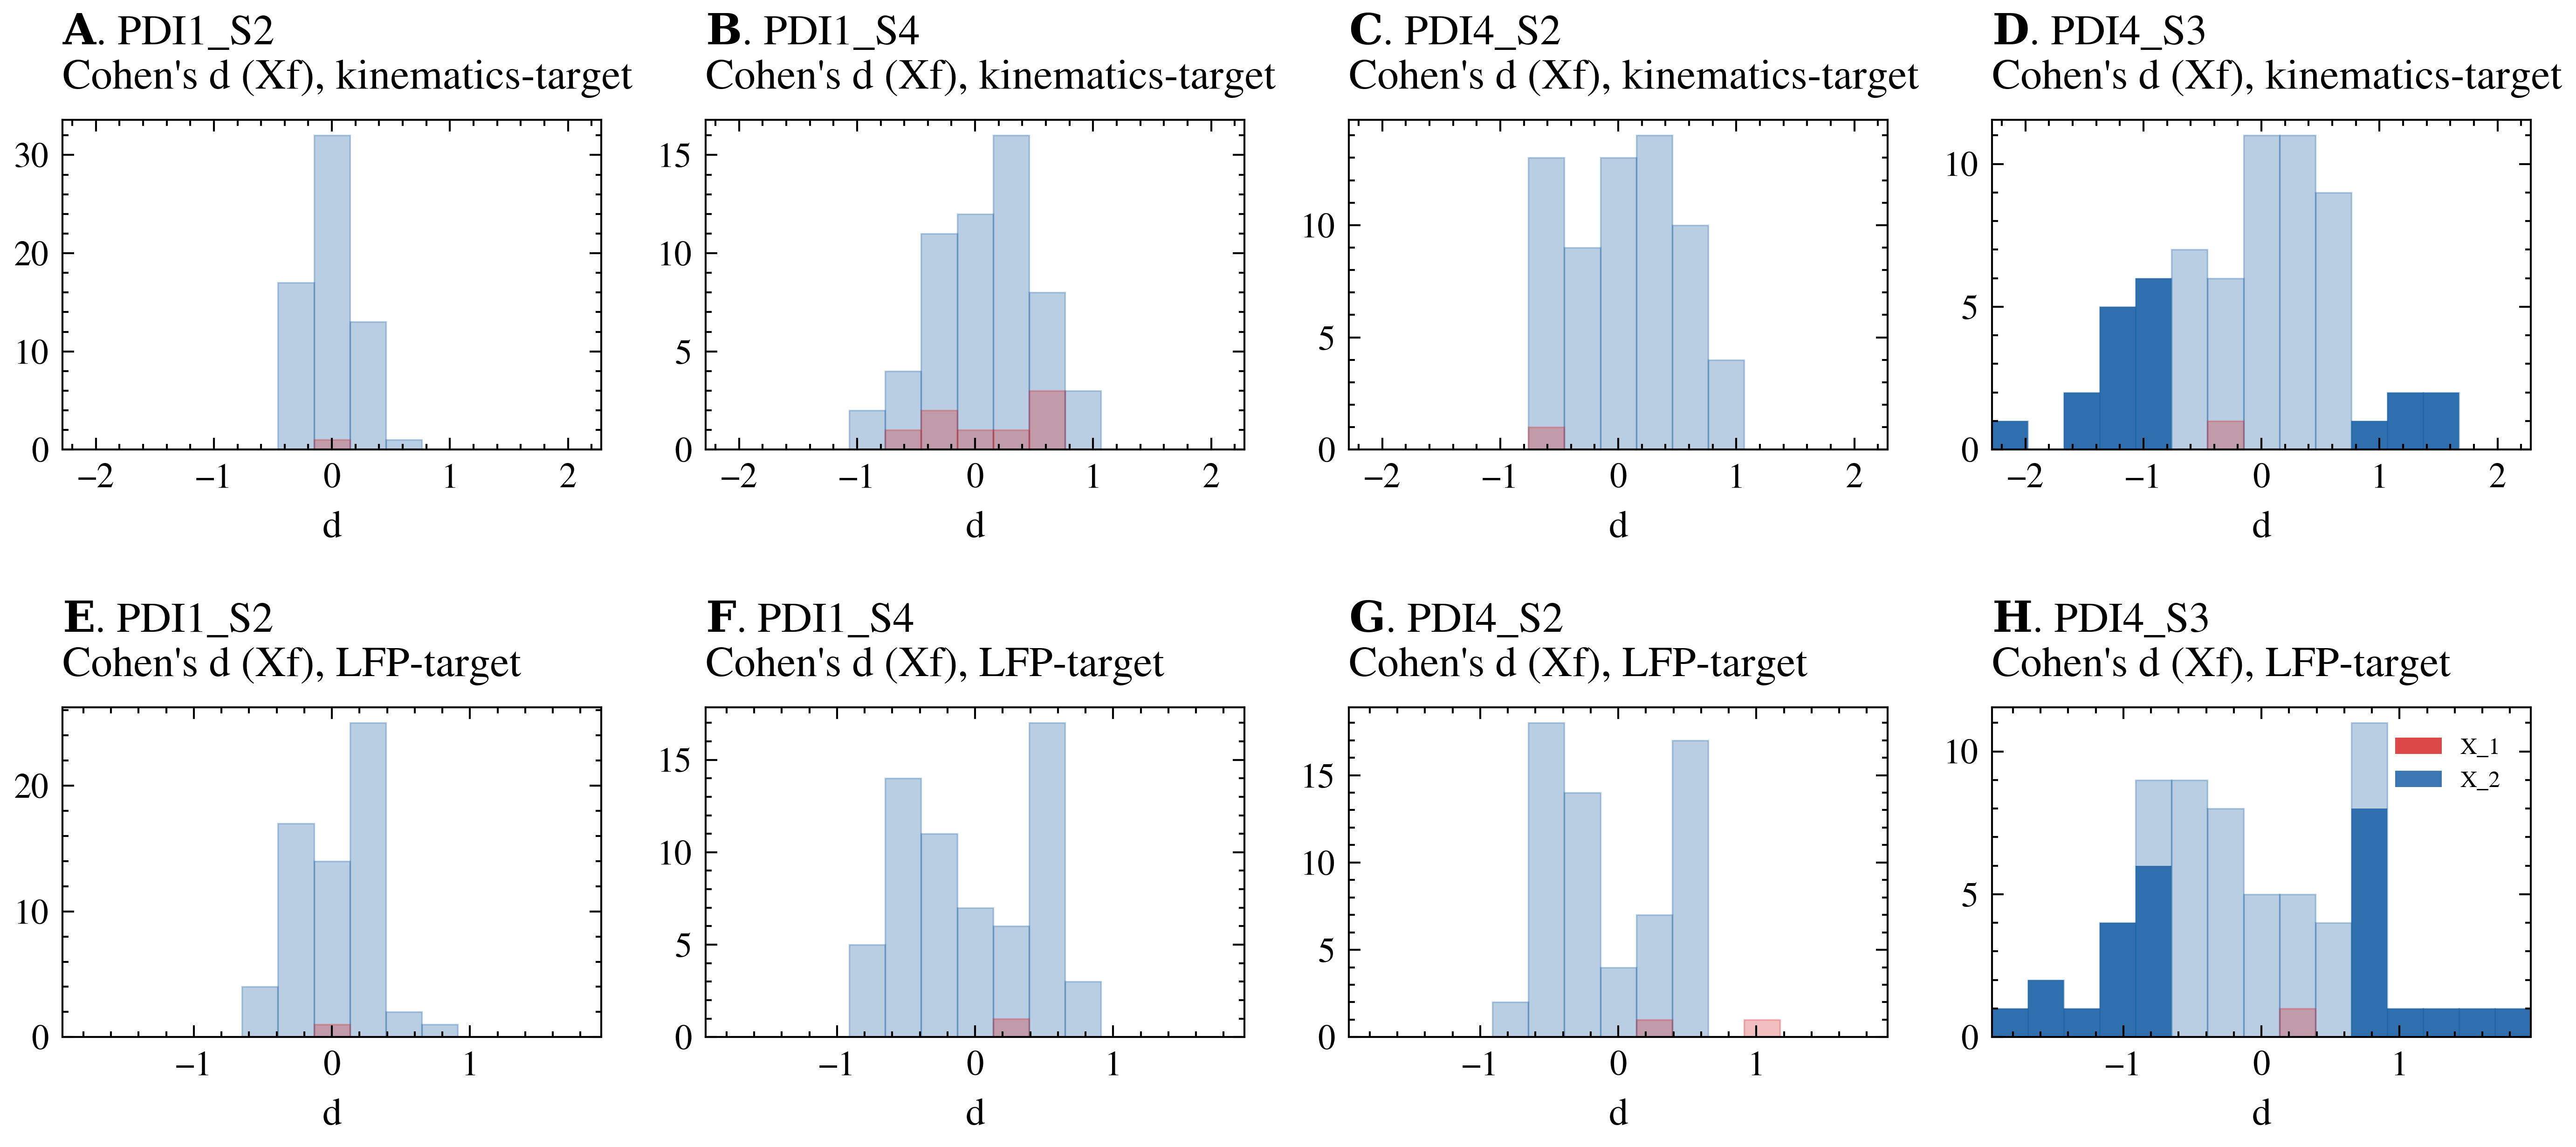


PSID Xf Cohen's d stats:
  [psid] PDI1_S2 / z-as-behavior: n_sig=0/64, mean|d|=0.193, max|d|=0.497
    X_1 (n=1): n_sig=0/1, mean|d|=0.118
    X_2 (n=63): n_sig=0/63, mean|d|=0.195
  [psid] PDI1_S4 / z-as-behavior: n_sig=0/64, mean|d|=0.381, max|d|=0.908
    X_1 (n=8): n_sig=0/8, mean|d|=0.414
    X_2 (n=56): n_sig=0/56, mean|d|=0.377
  [psid] PDI4_S2 / z-as-behavior: n_sig=0/64, mean|d|=0.398, max|d|=0.858
    X_1 (n=1): n_sig=0/1, mean|d|=0.671
    X_2 (n=63): n_sig=0/63, mean|d|=0.393
  [psid] PDI4_S3 / z-as-behavior: n_sig=19/64, mean|d|=0.595, max|d|=2.075
    X_1 (n=1): n_sig=0/1, mean|d|=0.293
    X_2 (n=63): n_sig=19/63, mean|d|=0.600
  [psid] PDI1_S2 / z-as-neural: n_sig=0/64, mean|d|=0.240, max|d|=0.651
    X_1 (n=1): n_sig=0/1, mean|d|=0.040
    X_2 (n=63): n_sig=0/63, mean|d|=0.243
  [psid] PDI1_S4 / z-as-neural: n_sig=0/64, mean|d|=0.418, max|d|=0.862
    X_1 (n=1): n_sig=0/1, mean|d|=0.275
    X_2 (n=63): n_sig=0/63, mean|d|=0.421
  [psid] PDI4_S2 / z-as-neural: n_sig=0/

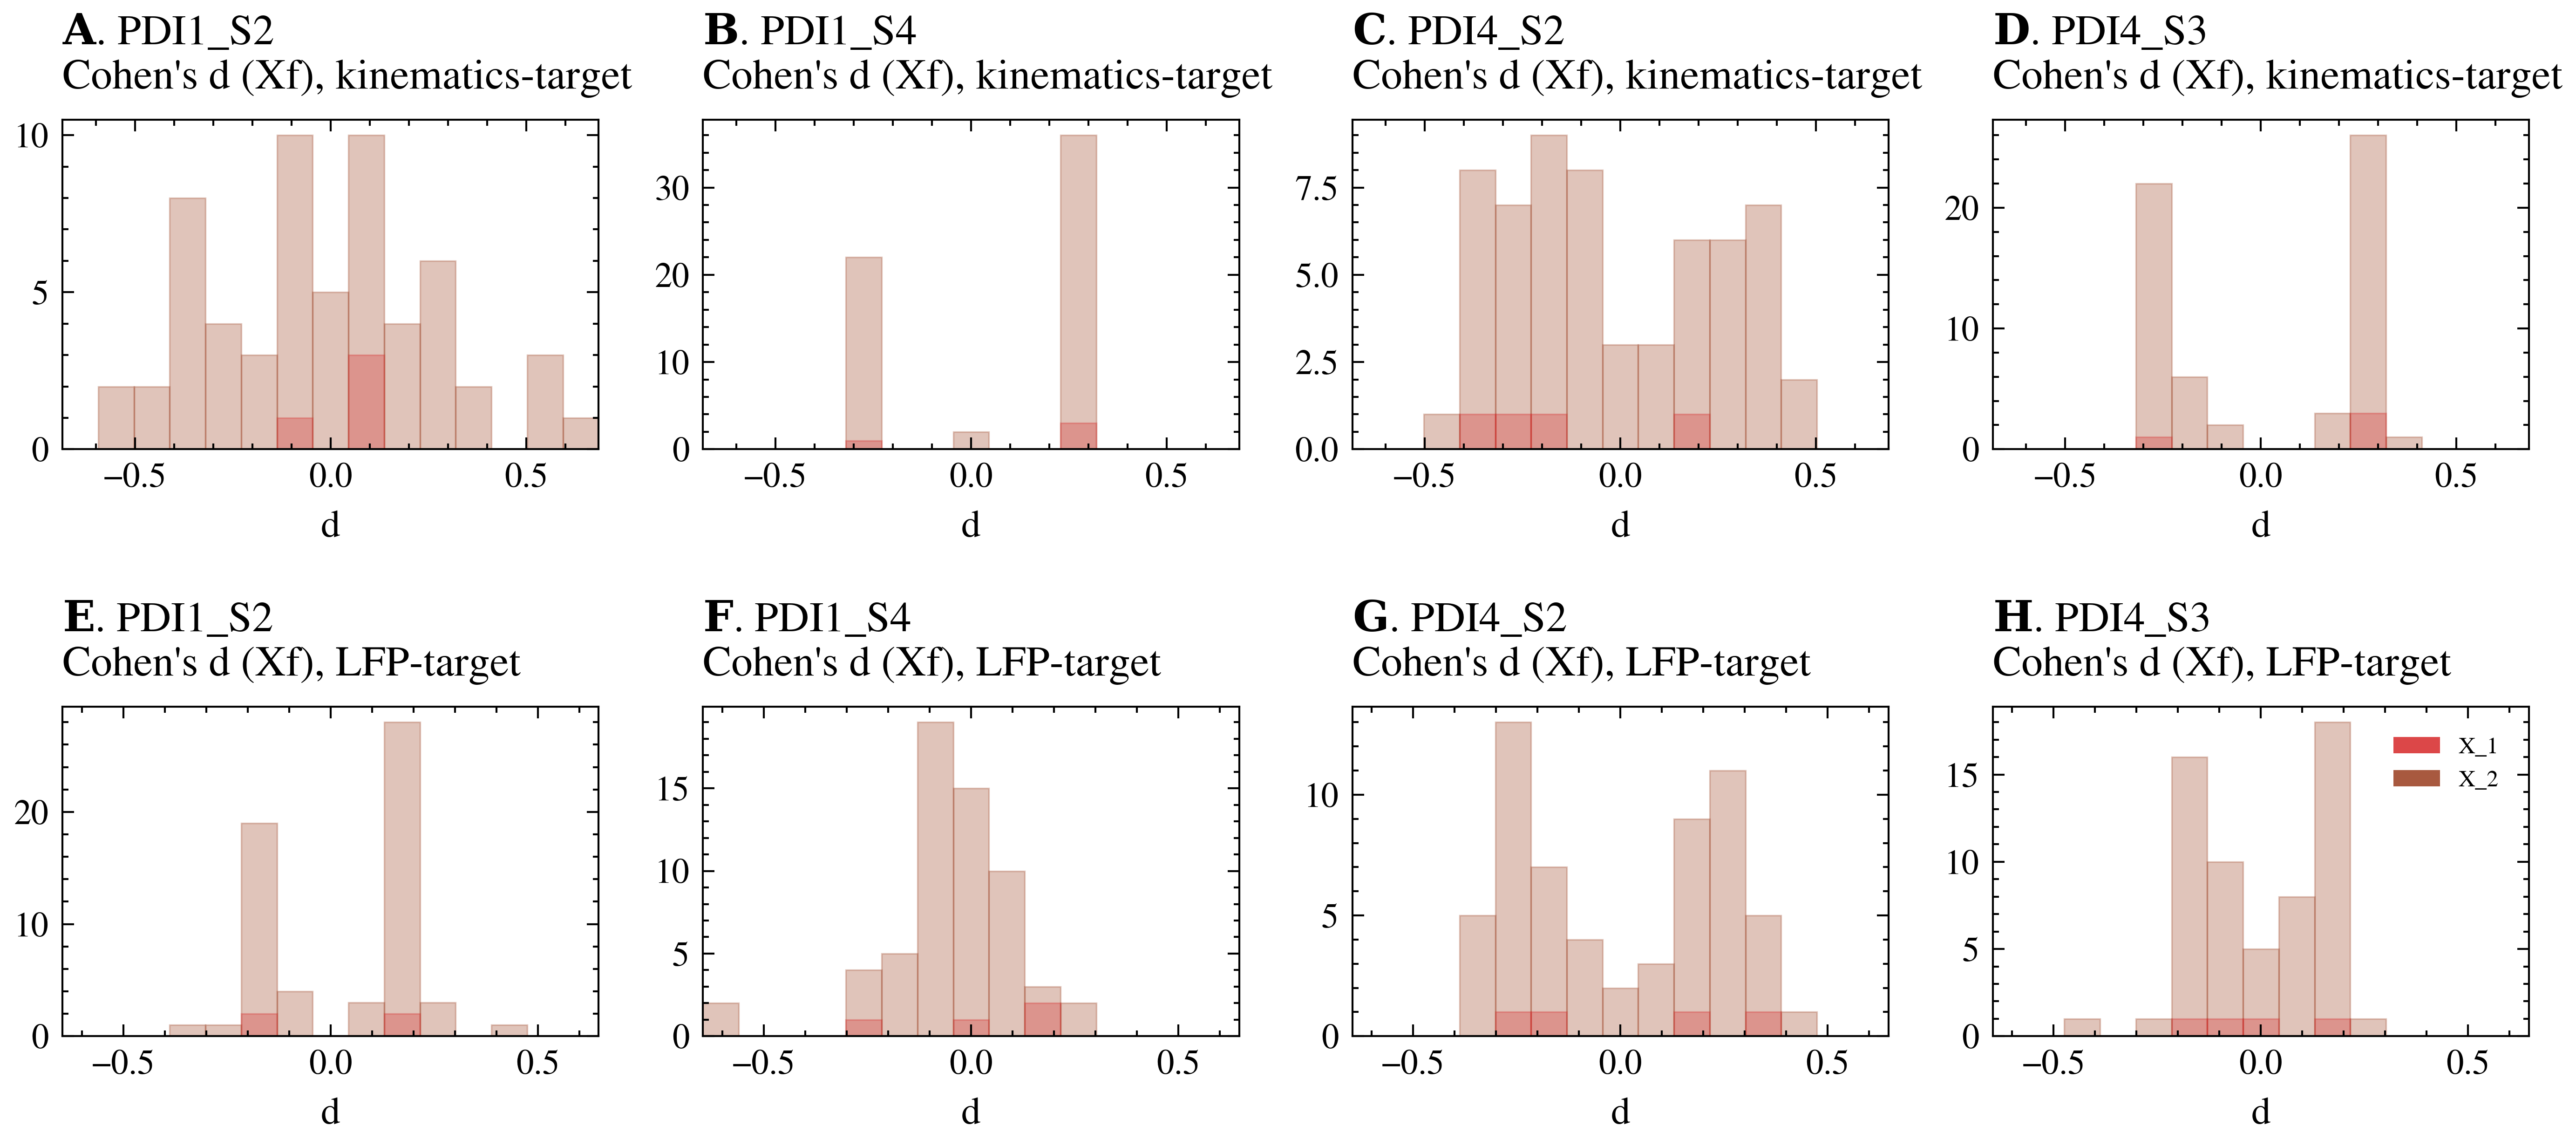


DPAD Xf Cohen's d stats:
  [dpad] PDI1_S2 / z-as-behavior: n_sig=0/64, mean|d|=0.221, max|d|=0.623
    X_1 (n=4): n_sig=0/4, mean|d|=0.067
    X_2 (n=60): n_sig=0/60, mean|d|=0.231
  [dpad] PDI1_S4 / z-as-behavior: n_sig=0/64, mean|d|=0.246, max|d|=0.254
    X_1 (n=4): n_sig=0/4, mean|d|=0.254
    X_2 (n=60): n_sig=0/60, mean|d|=0.245
  [dpad] PDI4_S2 / z-as-behavior: n_sig=0/64, mean|d|=0.232, max|d|=0.474
    X_1 (n=4): n_sig=0/4, mean|d|=0.275
    X_2 (n=60): n_sig=0/60, mean|d|=0.229
  [dpad] PDI4_S3 / z-as-behavior: n_sig=0/64, mean|d|=0.240, max|d|=0.378
    X_1 (n=4): n_sig=0/4, mean|d|=0.249
    X_2 (n=60): n_sig=0/60, mean|d|=0.240
  [dpad] PDI1_S2 / z-as-neural: n_sig=0/64, mean|d|=0.179, max|d|=0.393
    X_1 (n=4): n_sig=0/4, mean|d|=0.197
    X_2 (n=60): n_sig=0/60, mean|d|=0.178
  [dpad] PDI1_S4 / z-as-neural: n_sig=0/64, mean|d|=0.109, max|d|=0.588
    X_1 (n=4): n_sig=0/4, mean|d|=0.148
    X_2 (n=60): n_sig=0/60, mean|d|=0.107
  [dpad] PDI4_S2 / z-as-neural: n_sig=0/64

In [7]:
sessions_list = list(data.keys())
n_sessions = len(sessions_list)

dpad_n1_dict = {s: DPAD_N1 for s in sessions_list}

# --- pre-compute per-dim d + sig (Xf, h=0.5s) ----------------------------
XF_STATS = {}

for framework, exp_name, variant_dict, n1_dict in [
    ("psid", "z-as-behavior",
     {s: data[s]["run"]["variant"] for s in sessions_list},
     {s: data[s]["n1"] for s in sessions_list}),
    ("psid", "z-as-neural",
     {s: PSID_NEURAL_VARIANTS[s][0] for s in sessions_list},
     {s: PSID_NEURAL_VARIANTS[s][1] for s in sessions_list}),
    ("dpad", "z-as-behavior", DPAD_BEHAVIOR_VARIANTS, dpad_n1_dict),
    ("dpad", "z-as-neural", DPAD_NEURAL_VARIANTS, dpad_n1_dict),
]:
    for session in sessions_list:
        Xf_all, labels_s = load_xf_by_stim(variant_dict[session], h=0.5, framework=framework)
        stats_out = feature_trial_stats(Xf_all, labels_s)
        n1 = n1_dict.get(session)
        XF_STATS[(framework, exp_name, session)] = (
            np.array([r["d"] for r in stats_out]),
            np.array([r["reject_fdr"] for r in stats_out]),
            n1,
        )

EXP_NAMES = ["z-as-behavior", "z-as-neural"]

# ---- PSID Xf -------------------------------------------------------------
fig, axes = plt.subplots(2, n_sessions, figsize=(2.3 * n_sessions, 4.2))
if n_sessions == 1:
    axes = axes.reshape(2, 1)

vlim_psid = {}
for row_idx, exp_name in enumerate(EXP_NAMES):
    all_d = np.concatenate([XF_STATS[("psid", exp_name, s)][0] for s in sessions_list])
    vlim_psid[exp_name] = max(float(np.abs(all_d).max()), 0.1) * 1.1

for col_idx, session in enumerate(sessions_list):
    for row_idx, exp_name in enumerate(EXP_NAMES):
        ax = axes[row_idx, col_idx]
        d_arr, sig, n1 = XF_STATS[("psid", exp_name, session)]
        cohens_d_histogram(ax, d_arr, sig, n1=n1, color=COLOR_PSID, vlim=vlim_psid[exp_name])
        letter = chr(65 + row_idx * n_sessions + col_idx)
        session_us = session.replace(" ", "_")
        panel_label(ax, letter, f"{session_us}\nCohen's d (Xf), {pretty_exp(exp_name)}")

legend_psid = [
    Patch(facecolor="tab:red", alpha=0.85, label="X_1"),
    Patch(facecolor=COLOR_PSID, alpha=0.85, label="X_2"),
]
axes[-1, -1].legend(handles=legend_psid, loc="upper right", fontsize=6)

fig.savefig(str(OUT / "xf_psid_cohens_d_hist.png"))
plt.show()
print("\nPSID Xf Cohen's d stats:")
print_cohens_d_stats({k: v for k, v in XF_STATS.items() if k[0] == "psid"})

# ---- DPAD Xf -------------------------------------------------------------
fig, axes = plt.subplots(2, n_sessions, figsize=(2.3 * n_sessions, 4.2))
if n_sessions == 1:
    axes = axes.reshape(2, 1)

vlim_dpad = {}
for row_idx, exp_name in enumerate(EXP_NAMES):
    all_d = np.concatenate([XF_STATS[("dpad", exp_name, s)][0] for s in sessions_list])
    vlim_dpad[exp_name] = max(float(np.abs(all_d).max()), 0.1) * 1.1

for col_idx, session in enumerate(sessions_list):
    for row_idx, exp_name in enumerate(EXP_NAMES):
        ax = axes[row_idx, col_idx]
        d_arr, sig, n1 = XF_STATS[("dpad", exp_name, session)]
        cohens_d_histogram(ax, d_arr, sig, n1=n1, color=COLOR_DPAD, vlim=vlim_dpad[exp_name])
        letter = chr(65 + row_idx * n_sessions + col_idx)
        session_us = session.replace(" ", "_")
        panel_label(ax, letter, f"{session_us}\nCohen's d (Xf), {pretty_exp(exp_name)}")

legend_dpad = [
    Patch(facecolor="tab:red", alpha=0.85, label="X_1"),
    Patch(facecolor=COLOR_DPAD, alpha=0.85, label="X_2"),
]
axes[-1, -1].legend(handles=legend_dpad, loc="upper right", fontsize=6)

fig.savefig(str(OUT / "xf_dpad_cohens_d_hist.png"))
plt.show()
print("\nDPAD Xf Cohen's d stats:")
print_cohens_d_stats({k: v for k, v in XF_STATS.items() if k[0] == "dpad"})

## 7. Cy, Cz statistical comparison — PSID

L1-norm + one-sided t-test on element-wise differences between dbs_both, dbs_on, dbs_off models.
Sub-blocks split at n1 boundary (Xp1 vs Xp2 columns). No figures — text output only.

In [8]:
# --- Cy statistical comparison (L1 norm + one-sided t-test) -----------------
sessions_list = list(data.keys())
CONDS = ["dbs_both", "dbs_on", "dbs_off"]

for exp_label, variant_bases, n1_by_session in [
    (
        "z-as-behavior",
        {s: data[s]["run"]["variant"] for s in sessions_list},
        {s: data[s]["n1"] for s in sessions_list},
    ),
    (
        "z-as-neural",
        {s: PSID_NEURAL_VARIANTS[s][0] for s in sessions_list},
        {s: PSID_NEURAL_VARIANTS[s][1] for s in sessions_list},
    ),
]:
    for session in sessions_list:
        mats = {
            cond: load_model_matrices(variant_bases[session], cond)["Cy"]
            for cond in CONDS
        }
        print_matrix_comparison(
            f"Cy  {session}  {pretty_exp(exp_label)}",
            mats,
            n1_by_session[session],
        )


── Cy  PDI1 S2  kinematics-target ──
        pair          L1      mean Δ         t     p(H1: >0)     p(H1: <0)
--------------------------------------------------------------------------
dbs_on vs dbs_both    661.8026     -0.0229    -0.381        0.6483        0.3517
  block   ·1      7.3590     -0.0987
  block   ·2    654.4435     -0.0217
dbs_off vs dbs_both    580.7156     -0.0134    -0.234        0.5924        0.4076
  block   ·1      3.5687     -0.0982
  block   ·2    577.1469     -0.0120
dbs_on vs dbs_off    615.3978     -0.0095    -0.165        0.5653        0.4347
  block   ·1      4.1727     -0.0006
  block   ·2    611.2251     -0.0096


── Cy  PDI1 S4  kinematics-target ──
        pair          L1      mean Δ         t     p(H1: >0)     p(H1: <0)
--------------------------------------------------------------------------
dbs_on vs dbs_both    514.7130      0.0258     0.599        0.2746        0.7254
  block   ·1     76.1530      0.2150
  block   ·2    438.5599     -0.0012
dbs

In [9]:
# (Cy stats merged into cell above)

In [10]:
# --- Cz statistical comparison (L1 norm + one-sided t-test) -----------------
sessions_list = list(data.keys())
CONDS = ["dbs_both", "dbs_on", "dbs_off"]

for exp_label, variant_bases, n1_by_session in [
    (
        "z-as-behavior",
        {s: data[s]["run"]["variant"] for s in sessions_list},
        {s: data[s]["n1"] for s in sessions_list},
    ),
    (
        "z-as-neural",
        {s: PSID_NEURAL_VARIANTS[s][0] for s in sessions_list},
        {s: PSID_NEURAL_VARIANTS[s][1] for s in sessions_list},
    ),
]:
    for session in sessions_list:
        mats = {
            cond: load_model_matrices(variant_bases[session], cond)["Cz"]
            for cond in CONDS
        }
        print_matrix_comparison(
            f"Cz  {session}  {pretty_exp(exp_label)}",
            mats,
            n1_by_session[session],
        )


── Cz  PDI1 S2  kinematics-target ──
        pair          L1      mean Δ         t     p(H1: >0)     p(H1: <0)
--------------------------------------------------------------------------
dbs_on vs dbs_both  27320.9234     21.6415     0.556        0.2896        0.7104
  block   ·1   3076.7426   1538.3713
  block   ·2  24244.1808     -2.4336
dbs_off vs dbs_both  32044.0857     11.5220     0.225        0.4113        0.5887
  block   ·1   1479.4679    739.7340
  block   ·2  30564.6178     -0.0369
dbs_on vs dbs_off  30312.0637     10.1194     0.210        0.4170        0.5830
  block   ·1   1597.2747    798.6374
  block   ·2  28714.7890     -2.3967


── Cz  PDI1 S4  kinematics-target ──
        pair          L1      mean Δ         t     p(H1: >0)     p(H1: <0)
--------------------------------------------------------------------------
dbs_on vs dbs_both  48286.2987     94.1926     1.024        0.1539        0.8461
  block   ·1  26141.3800    614.4488
  block   ·2  22144.9187     19.8703
dbs

In [11]:
# (Cz stats merged into cell above)

## Interpretation guide

- **§3 Xp (PSID + DPAD)**: Cohen's d histogram across 64 latent dims. Red = Xp1 (behavioral subspace, PSID only), model-color = Xp2 (PSID) / all dims (DPAD). Light fill = all dims, solid fill = FDR significant (q<0.05). Wide spread away from 0 = DBS label encoded.
- **§4 A-matrix (PSID)**: L1 norm + one-sided t-test comparing A matrices across dbs_both/on/off conditions. Sub-blocks show which coupling directions (Xp1↔Xp1, Xp1↔Xp2, etc.) differ most. p(H1: >0) tests whether one condition's weights are systematically larger.
- **§6 Xf (PSID + DPAD)**: Same histogram layout as §3 but on h=0.5s forecast latent — tests whether DBS structure survives into the forecast horizon.
- **§7 Cy/Cz (PSID)**: Same L1 + t-test approach as §4, applied to Cy (ECoG readout, nY×nx) and Cz (Z readout, nZ×nx). Sub-blocks split at n1 (Xp1 vs Xp2 columns).